# 03 — Fine-tune YOLO-World on VisDrone

Goal: Adapt the pretrained YOLO-World model to aerial drone imagery
by fine-tuning on VisDrone DET. This is the core training step of
the project. After this notebook, mAP@0.5 should roughly double
compared to the 0.1036 pretrained baseline.

Sections:
  A) Pre-training analysis — class imbalance, data verifxication
  B) Copy training data to local SSD (avoids Drive I/O bottleneck)
  C) Fine-tune YOLO-World on VisDrone
  D) Resume cell (run ONLY if session resets during training)
  E) Save checkpoint + training results to Drive
  F) Evaluate fine-tuned model vs pretrained baseline
  G) Save comparison charts and tables to Drive


In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 0a: Install all packages
# Run this cell fully before running Cell 0b.
# ─────────────────────────────────────────────────────────────
import subprocess, sys

def install(pkg, label=None):
    label = label or pkg
    print(f"  Installing {label}...", end=" ", flush=True)
    r = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True
    )
    print("✅" if r.returncode == 0 else f"❌\n{r.stderr[-300:]}")

print("Installing packages...")
install("ultralytics==8.3.145",   "ultralytics (pinned 8.3.145)")
install("supervision",            "supervision")
install("albumentations",         "albumentations")
install("pycocotools",            "pycocotools")
install("einops",                 "einops")
install("opencv-python-headless", "opencv-headless")
install("hydra-core",             "hydra-core")
install("iopath",                 "iopath")
install("submitit",               "submitit")
install("git+https://github.com/ultralytics/CLIP.git", "CLIP")

print("\n✅ All packages installed.")
print("   → Now run Cell 0b.")

Installing packages...
  Installing ultralytics (pinned 8.3.145)... ✅
  Installing supervision... ✅
  Installing albumentations... ✅
  Installing pycocotools... ✅
  Installing einops... ✅
  Installing opencv-headless... ✅
  Installing hydra-core... ✅
  Installing iopath... ✅
  Installing submitit... ✅
  Installing CLIP... ✅

✅ All packages installed.
   → Now run Cell 0b.


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 0b: Clone repos, set sys.path, verify all imports
# Run AFTER Cell 0a has fully completed.
# ─────────────────────────────────────────────────────────────
import subprocess, sys, os, importlib

importlib.invalidate_caches()

# Clear stale module cache
for mod in list(sys.modules.keys()):
    if mod in ("sam2", "ultralytics", "hydra") or \
       mod.startswith(("sam2.", "ultralytics.", "hydra.")):
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive')

import json
CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

YOLOWORLD_REPO = cfg["yoloworld_repo"]
SAM2_REPO      = cfg["sam2_repo"]

def clone_if_missing(repo_path, url, name):
    if not os.path.exists(repo_path):
        print(f"  Cloning {name}...", end=" ", flush=True)
        r = subprocess.run(f"git clone -q {url} {repo_path}",
                           shell=True, capture_output=True, text=True)
        print("✅" if r.returncode == 0 else f"❌ {r.stderr[-100:]}")
    else:
        print(f"  {name} already present ✅")

clone_if_missing(YOLOWORLD_REPO,
                 "https://github.com/AILab-CVC/YOLO-World.git", "YOLO-World")
clone_if_missing(SAM2_REPO,
                 "https://github.com/facebookresearch/sam2.git", "SAM-2")

# Add ONLY SAM-2 to sys.path — NOT YOLO-World
if SAM2_REPO not in sys.path:
    sys.path.insert(0, SAM2_REPO)

print("\nVerifying imports...")
import torch
print(f"  torch      : {torch.__version__} | CUDA: {torch.cuda.is_available()}")
try:
    import ultralytics
    from ultralytics import YOLO
    print(f"  ultralytics: {ultralytics.__version__} ✅")
except Exception as e:
    print(f"  ultralytics: ❌ {e}")
try:
    import hydra
    print(f"  hydra-core : {hydra.__version__} ✅")
except Exception as e:
    print(f"  hydra-core : ❌ {e}  ← re-run Cell 0a if this fails")
try:
    import cv2
    print(f"  opencv     : {cv2.__version__} ✅")
except Exception as e:
    print(f"  opencv     : ❌ {e}")

print("\n✅ Cell 0b complete. Run Cell 1 next.")

Mounted at /content/drive
  Cloning YOLO-World... ✅
  Cloning SAM-2... ✅

Verifying imports...
  torch      : 2.10.0+cu128 | CUDA: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ultralytics: 8.3.145 ✅
  hydra-core : 1.3.2 ✅
  opencv     : 4.13.0 ✅

✅ Cell 0b complete. Run Cell 1 next.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Imports, config, all path variables, staging dirs
# ─────────────────────────────────────────────────────────────
import json, os, sys, shutil, subprocess, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

# ── Paths from config ─────────────────────────────────────────
PROC_VISDRONE   = cfg["proc_visdrone"]
OUTPUT_DIR      = cfg["output_dir"]
VIZ_DIR         = cfg["viz_dir"]
METRICS_DIR     = cfg["metrics_dir"]
TABLES_DIR      = cfg["tables_dir"]
CKPT_YOLOWORLD  = cfg["ckpt_yoloworld"]
YW_CKPT_PATH    = cfg["yw_ckpt_path"]       # pretrained checkpoint
DEVICE          = cfg.get("device", "cuda")
CONFIGS_DIR     = cfg["configs_dir"]

VD_TRAIN_IMG    = cfg["proc_vd_img_train"]
VD_TRAIN_LBL    = cfg["proc_vd_lbl_train"]
VD_VAL_IMG      = cfg["proc_vd_img_val"]
VD_VAL_LBL      = cfg["proc_vd_lbl_val"]
STRESS_JSON     = os.path.join(PROC_VISDRONE, "stress_set.json")
CLASS_DIST_CSV  = os.path.join(PROC_VISDRONE, "class_dist.csv")
VISDRONE_YAML   = os.path.join(PROC_VISDRONE, "visdrone.yaml")

# Fine-tuned checkpoint path (written after training)
YW_FT_CKPT_PATH = os.path.join(CKPT_YOLOWORLD, "yolov8l-world-finetuned.pt")

# Local training dirs (fast SSD, avoids Drive I/O during training)
LOCAL_TRAIN_DIR  = "/content/visdrone"
LOCAL_YAML_PATH  = "/content/visdrone_local.yaml"
LOCAL_RUNS_DIR   = "/content/runs"
LOCAL_CKPT_BACKUP = "/content/drive/MyDrive/DLCV_OV_Analytics/checkpoints/yoloworld/last_backup.pt"

# ── Class definitions (must match visdrone.yaml) ──────────────
YOLO_CLASSES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor", "others"
]

# ── Local staging for Drive outputs ───────────────────────────
STAGE          = "/content/staging/finetune"
STAGE_METRICS  = f"{STAGE}/metrics"
STAGE_VIZ      = f"{STAGE}/visualizations/finetune_results"
STAGE_TABLES   = f"{STAGE}/tables"
for d in [STAGE_METRICS, STAGE_VIZ, STAGE_TABLES]:
    os.makedirs(d, exist_ok=True)

def cp_sync(src, dst_dir):
    """Copy file to Drive using OS cp + sync. Reliable on FUSE mounts."""
    r = subprocess.run(f"cp '{src}' '{dst_dir}/' && sync",
                       shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise IOError(f"cp failed: {r.stderr}")
    dst = os.path.join(dst_dir, os.path.basename(src))
    return dst, os.path.getsize(dst)

# ── Verify all inputs exist ───────────────────────────────────
print("Verifying inputs...")
all_ok = True
for name, path in [
    ("VD train images",  VD_TRAIN_IMG),
    ("VD train labels",  VD_TRAIN_LBL),
    ("VD val images",    VD_VAL_IMG),
    ("VD val labels",    VD_VAL_LBL),
    ("visdrone.yaml",    VISDRONE_YAML),
    ("class_dist.csv",   CLASS_DIST_CSV),
    ("stress_set.json",  STRESS_JSON),
    ("YOLO-World ckpt",  YW_CKPT_PATH),
]:
    exists = os.path.exists(path)
    if os.path.isdir(path):
        n = len(os.listdir(path))
        print(f"  {'✅' if exists else '❌ MISSING'}  {name}: {n:,} files")
    else:
        print(f"  {'✅' if exists else '❌ MISSING'}  {name}")
    if not exists:
        all_ok = False

if all_ok:
    print(f"\n✅ Cell 1 complete. Device: {DEVICE}")
else:
    print("\n❌ Fix missing inputs before continuing.")

Verifying inputs...
  ✅  VD train images: 6,471 files
  ✅  VD train labels: 6,471 files
  ✅  VD val images: 548 files
  ✅  VD val labels: 548 files
  ✅  visdrone.yaml
  ✅  class_dist.csv
  ✅  stress_set.json
  ✅  YOLO-World ckpt

✅ Cell 1 complete. Device: cuda


  VisDrone Train — Class Distribution
  Total boxes: 344,736

  car                   144,866  ( 42.0%)  █████████████████████
  pedestrian             79,337  ( 23.0%)  ███████████
  motor                  29,647  (  8.6%)  ████
  people                 27,059  (  7.8%)  ███
  van                    24,956  (  7.2%)  ███
  truck                  12,875  (  3.7%)  █
  bicycle                10,480  (  3.0%)  █
  bus                     5,926  (  1.7%)  
  tricycle                4,812  (  1.4%)  
  awning-tricycle         3,246  (  0.9%)  
  others                  1,532  (  0.4%)  


/tmp/ipykernel_5524/2558170076.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(train_dist["class_name"], rotation=30, ha="right")


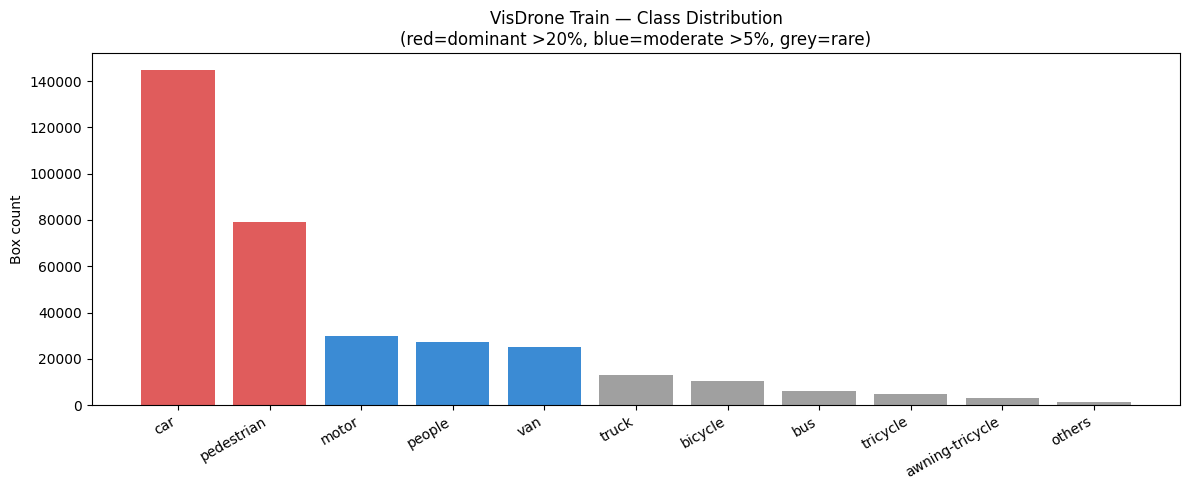


  Training Strategy

  Class imbalance observations:
  - car dominates (~42% of boxes) — model will naturally learn this well
  - pedestrian is strong (~23%) — also well-represented
  - people, motor, others are underrepresented (<5% each)
  - awning-tricycle, tricycle are rare (<3% each)

  Strategy applied:
  - No manual class weights (ultralytics handles class balance
    automatically via cls loss weighting in focal loss)
  - mosaic=1.0: mosaic augmentation groups 4 images — artificially
    increases rare-class exposure per batch
  - Small object focus: imgsz=640 with scale augmentation
  - close_mosaic=10: disable mosaic last 10 epochs for convergence
  - Expected: car/pedestrian improve most; people/motor improve
    significantly from near-zero baseline

  visdrone.yaml contents
  path: /content/drive/MyDrive/DLCV_OV_Analytics/datasets/processed/visdrone
  train: images/train
  val: images/val
  test: images/test
  nc: 11
  names: ['pedestrian', 'people', 'bicycle', 'car', 'va

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 2: Pre-training analysis
# Examine class imbalance and confirm data is ready
# ─────────────────────────────────────────────────────────────

# ── Load class distribution ───────────────────────────────────
df_dist = pd.read_csv(CLASS_DIST_CSV)
train_dist = df_dist[df_dist["split"] == "train"].copy()
train_dist = train_dist.sort_values("count", ascending=False)

total_boxes = train_dist["count"].sum()
train_dist["pct"] = (train_dist["count"] / total_boxes * 100).round(1)

print("=" * 55)
print("  VisDrone Train — Class Distribution")
print("=" * 55)
print(f"  Total boxes: {total_boxes:,}\n")
for _, row in train_dist.iterrows():
    bar = "█" * int(row["pct"] / 2)
    print(f"  {row['class_name']:<20} {row['count']:>8,}  ({row['pct']:>5.1f}%)  {bar}")

# ── Chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#E05C5C" if p > 20 else "#3B8BD4" if p > 5 else "#A0A0A0"
          for p in train_dist["pct"]]
ax.bar(train_dist["class_name"], train_dist["count"], color=colors)
ax.set_xticklabels(train_dist["class_name"], rotation=30, ha="right")
ax.set_ylabel("Box count")
ax.set_title("VisDrone Train — Class Distribution\n"
             "(red=dominant >20%, blue=moderate >5%, grey=rare)")
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Training strategy notes ───────────────────────────────────
print("\n" + "=" * 55)
print("  Training Strategy")
print("=" * 55)
print("""
  Class imbalance observations:
  - car dominates (~42% of boxes) — model will naturally learn this well
  - pedestrian is strong (~23%) — also well-represented
  - people, motor, others are underrepresented (<5% each)
  - awning-tricycle, tricycle are rare (<3% each)

  Strategy applied:
  - No manual class weights (ultralytics handles class balance
    automatically via cls loss weighting in focal loss)
  - mosaic=1.0: mosaic augmentation groups 4 images — artificially
    increases rare-class exposure per batch
  - Small object focus: imgsz=640 with scale augmentation
  - close_mosaic=10: disable mosaic last 10 epochs for convergence
  - Expected: car/pedestrian improve most; people/motor improve
    significantly from near-zero baseline
""")

# ── Verify visdrone.yaml ──────────────────────────────────────
print("=" * 55)
print("  visdrone.yaml contents")
print("=" * 55)
with open(VISDRONE_YAML) as f:
    yd = yaml.safe_load(f)
for k, v in yd.items():
    print(f"  {k}: {v}")

# ── Count images ──────────────────────────────────────────────
n_train = len([f for f in os.listdir(VD_TRAIN_IMG) if f.endswith(".jpg")])
n_val   = len([f for f in os.listdir(VD_VAL_IMG)   if f.endswith(".jpg")])
print(f"\n  Train images : {n_train:,}")
print(f"  Val images   : {n_val:,}")
print("\n✅ Cell 2 complete. Data is ready for training.")

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3: Copy VisDrone training data to local Colab SSD
#
# WHY: Training reads images thousands of times across epochs.
# Reading from Drive (FUSE mount) is ~10x slower than local SSD.
# Copying once up-front saves hours of training time.
# VisDrone train+val ≈ 7-10 GB — fits in Colab's local storage.
# ─────────────────────────────────────────────────────────────
import shutil

LOCAL_IMG_TRAIN = f"{LOCAL_TRAIN_DIR}/images/train"
LOCAL_LBL_TRAIN = f"{LOCAL_TRAIN_DIR}/labels/train"
LOCAL_IMG_VAL   = f"{LOCAL_TRAIN_DIR}/images/val"
LOCAL_LBL_VAL   = f"{LOCAL_TRAIN_DIR}/labels/val"

for d in [LOCAL_IMG_TRAIN, LOCAL_LBL_TRAIN, LOCAL_IMG_VAL, LOCAL_LBL_VAL]:
    os.makedirs(d, exist_ok=True)

def copy_dir_if_empty(src, dst, desc):
    existing = len(os.listdir(dst))
    expected = len(os.listdir(src))
    if existing >= expected:
        print(f"  ✅ {desc}: already on SSD ({existing:,} files)")
        return
    print(f"  Copying {desc} ({expected:,} files)...", end=" ", flush=True)
    t0 = time.time()
    for fname in os.listdir(src):
        shutil.copy2(os.path.join(src, fname), os.path.join(dst, fname))
    print(f"✅  [{time.time()-t0:.0f}s]")

print("Copying VisDrone data to local SSD...")
copy_dir_if_empty(VD_TRAIN_IMG, LOCAL_IMG_TRAIN, "train images")
copy_dir_if_empty(VD_TRAIN_LBL, LOCAL_LBL_TRAIN, "train labels")
copy_dir_if_empty(VD_VAL_IMG,   LOCAL_IMG_VAL,   "val images")
copy_dir_if_empty(VD_VAL_LBL,   LOCAL_LBL_VAL,   "val labels")

# ── Write local yaml pointing to /content/visdrone/ ───────────
local_yaml = {
    "path"  : LOCAL_TRAIN_DIR,
    "train" : "images/train",
    "val"   : "images/val",
    "test"  : "images/val",    # use val as test (no test GT labels)
    "nc"    : len(YOLO_CLASSES),
    "names" : YOLO_CLASSES,
}
with open(LOCAL_YAML_PATH, "w") as f:
    yaml.dump(local_yaml, f, default_flow_style=False, sort_keys=False)

print(f"\n✅ Local yaml written: {LOCAL_YAML_PATH}")

# ── Verify ────────────────────────────────────────────────────
print("\nVerifying local data:")
for desc, path in [
    ("train images", LOCAL_IMG_TRAIN),
    ("train labels", LOCAL_LBL_TRAIN),
    ("val images",   LOCAL_IMG_VAL),
    ("val labels",   LOCAL_LBL_VAL),
]:
    n = len(os.listdir(path))
    print(f"  ✅ {desc}: {n:,} files")

# Check free disk space
result = subprocess.run("df -h /content", shell=True,
                        capture_output=True, text=True)
print(f"\nDisk usage:\n{result.stdout}")
print("✅ Cell 3 complete. Training data on local SSD.")

Copying VisDrone data to local SSD...
  Copying train images (6,471 files)... ✅  [229s]
  Copying train labels (6,471 files)... ✅  [93s]
  Copying val images (548 files)... ✅  [7s]
  Copying val labels (548 files)... ✅  [5s]

✅ Local yaml written: /content/visdrone_local.yaml

Verifying local data:
  ✅ train images: 6,471 files
  ✅ train labels: 6,471 files
  ✅ val images: 548 files
  ✅ val labels: 548 files

Disk usage:
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   47G  190G  20% /

✅ Cell 3 complete. Training data on local SSD.


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 4: Fine-tune YOLO-World on VisDrone
#
# Expected time: 2-3 hours on T4 (50 epochs)
# Keep this tab active to prevent Colab from disconnecting.
# A Drive backup of last.pt is saved after every epoch via
# callback so you can resume if the session resets.
#
# DO NOT run this cell if training already completed —
# jump straight to Cell 6 to save the checkpoint.
# ─────────────────────────────────────────────────────────────
import torch
from ultralytics import YOLO
from ultralytics.utils.callbacks.base import add_integration_callbacks

# ── Check if fine-tuned checkpoint already exists ─────────────
if os.path.exists(YW_FT_CKPT_PATH):
    size_mb = os.path.getsize(YW_FT_CKPT_PATH) / 1e6
    print(f"✅ Fine-tuned checkpoint already exists ({size_mb:.1f} MB):")
    print(f"   {YW_FT_CKPT_PATH}")
    print("   Skip this cell and run Cell 6 to verify/evaluate.")
else:
    print(f"Starting fine-tuning from: {YW_CKPT_PATH}")
    print(f"Training data: {LOCAL_YAML_PATH}")
    print(f"Output dir: {LOCAL_RUNS_DIR}/finetune")
    print(f"Device: {DEVICE}")
    print()

    # ── Load model ────────────────────────────────────────────
    model = YOLO(YW_CKPT_PATH)

    # ── Callback: backup last.pt to Drive after every epoch ──
    # This is the session-reset recovery mechanism.
    # If Colab disconnects, last_backup.pt on Drive lets you resume.
    def on_train_epoch_end(trainer):
        """Copy last.pt to Drive after each epoch for session-reset recovery."""
        last_pt = os.path.join(trainer.save_dir, "weights", "last.pt")
        if os.path.exists(last_pt):
            os.makedirs(os.path.dirname(LOCAL_CKPT_BACKUP), exist_ok=True)
            subprocess.run(
                f"cp '{last_pt}' '{LOCAL_CKPT_BACKUP}' && sync",
                shell=True
            )

    model.add_callback("on_train_epoch_end", on_train_epoch_end)

    # ── Train ─────────────────────────────────────────────────
    results = model.train(
        data       = LOCAL_YAML_PATH,
        epochs     = 50,
        imgsz      = 640,
        batch      = 8,           # safe for T4 15GB; increase to 16 on A100
        optimizer  = "AdamW",
        lr0        = 0.001,       # lower LR for fine-tuning (default=0.01)
        lrf        = 0.01,        # final LR = lr0 * lrf
        momentum   = 0.937,
        weight_decay = 0.0005,
        warmup_epochs = 3.0,
        warmup_momentum = 0.8,
        box        = 7.5,         # box loss weight
        cls        = 0.5,         # class loss weight
        dfl        = 1.5,         # distribution focal loss weight
        mosaic     = 1.0,         # mosaic augmentation — good for small objects
        mixup      = 0.0,         # disable mixup for detection
        copy_paste = 0.0,
        degrees    = 0.0,         # no rotation — aerial objects are upright
        translate  = 0.1,
        scale      = 0.5,
        shear      = 0.0,
        perspective = 0.0,
        flipud     = 0.5,         # vertical flip valid for aerial view
        fliplr     = 0.5,
        hsv_h      = 0.015,
        hsv_s      = 0.7,
        hsv_v      = 0.4,
        close_mosaic = 10,        # disable mosaic last 10 epochs for stability
        patience   = 20,          # early stopping if no improvement for 20 epochs
        save_period = 5,          # save checkpoint every 5 epochs
        project    = LOCAL_RUNS_DIR,
        name       = "finetune",
        exist_ok   = True,        # allows re-running without collision
        verbose    = True,
        device     = 0 if torch.cuda.is_available() else "cpu",           # GPU 0
    )

    print("\n✅ Training complete.")
    print(f"   Best checkpoint: {LOCAL_RUNS_DIR}/finetune/weights/best.pt")
    print(f"   Run Cell 6 to save checkpoint and results to Drive.")

Starting fine-tuning from: /content/drive/MyDrive/DLCV_OV_Analytics/checkpoints/yoloworld/yolov8l-world.pt
Training data: /content/visdrone_local.yaml
Output dir: /content/runs/finetune
Device: cuda

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.145 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visdrone_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, 

100%|██████████| 755k/755k [00:00<00:00, 18.2MB/s]

Overriding model.yaml nc=80 with nc=11

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytic

  8                  -1  3   4461568  ultralytics.nn.modules.block.C2f             [512, 512, 3, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  3   5576456  ultralytics.nn.modules.block.C2fAttn         [1024, 512, 3, 256, 8]        
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  3   1493892  ultralytics.nn.modules.block.C2fAttn         [768, 256, 3, 128, 4]         
 16         [15, 12, 9]  1    724992  ultralytics.nn.modules.block.ImagePoolingAttn[256,

100%|██████████| 5.35M/5.35M [00:00<00:00, 73.7MB/s]


...

                   all        548      38791      0.485      0.414      0.411      0.252

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/809 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
      50/50      11.7G       1.08      0.648     0.8809        333        640: 100%|██████████| 809/809 [01:51<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:04<00:00,  8.25it/s]


                   all        548      38791      0.486      0.406      0.411      0.252

50 epochs completed in 1.655 hours.
Optimizer stripped from /content/runs/finetune/weights/last.pt, 95.5MB
Optimizer stripped from /content/runs/finetune/weights/best.pt, 95.5MB

Validating /content/runs/finetune/weights/best.pt...
Ultralytics 8.3.145 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv8l-world summary (fused): 140 layers, 47,529,842 parameters, 0 gradients, 185.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 35/35 [00:11<00:00,  3.10it/s]


                   all        548      38791      0.503      0.406      0.412      0.252
            pedestrian        520       8844       0.59      0.439      0.488      0.234
                people        482       5125      0.608      0.306      0.371       0.15
               bicycle        364       1287      0.316      0.231      0.184     0.0854
                   car        515      14064      0.761      0.785      0.819      0.594
                   van        421       1975      0.507        0.5       0.49       0.35
                 truck        266        750      0.567      0.424      0.446      0.304
              tricycle        337       1045      0.493      0.376      0.372      0.213
       awning-tricycle        220        532      0.322       0.25      0.207      0.134
                   bus        131        251      0.661       0.57       0.62      0.455
                 motor        485       4886      0.561      0.473      0.487      0.229
                other

✅ best.pt found (95.5 MB)
✅ Fine-tuned checkpoint saved to Drive:
   /content/drive/MyDrive/DLCV_OV_Analytics/checkpoints/yoloworld/yolov8l-world-finetuned.pt (95.5 MB)
✅ results.csv copied to staging
✅ training curves copied to staging
✅ confusion matrix copied to staging
✅ config.json updated with fine-tuned checkpoint path


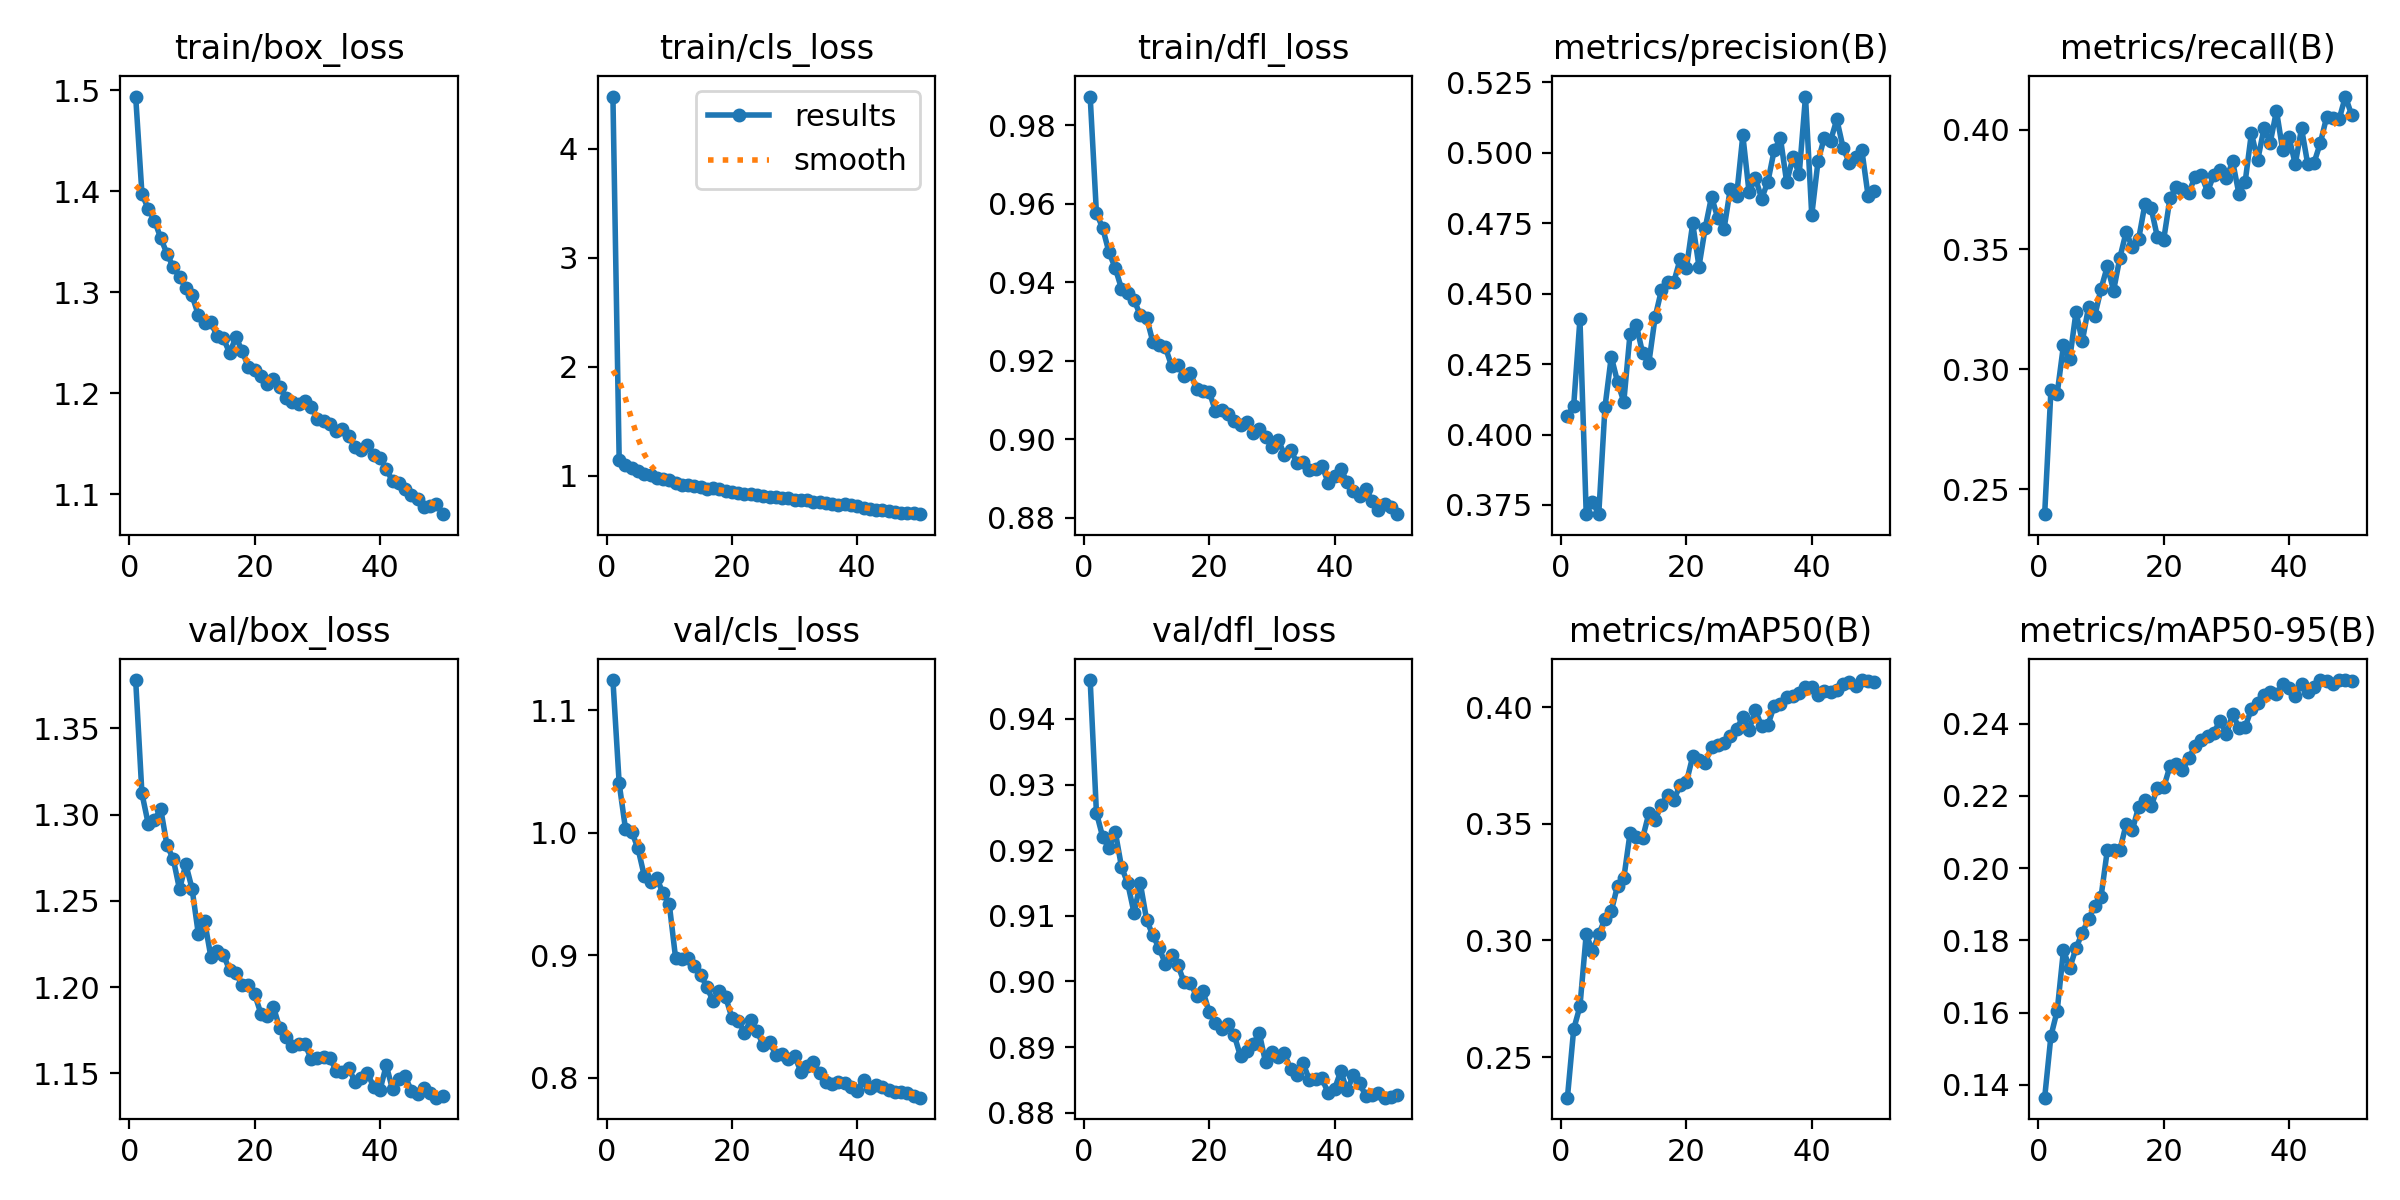


  Best epoch: 49
  Val mAP@0.5: 0.4117

  Training results:
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    46 5484.30         1.09548         0.66702         0.88435               0.49632            0.40515           0.41099              0.25179       1.13805       0.78808       0.88271 0.000109 0.000109 0.000109
    47 5602.96         1.08691         0.65947         0.88210               0.49866            0.40499           0.40917              0.25092       1.14124       0.78871       0.88301 0.000089 0.000089 0.000089
    48 5721.37         1.08861         0.65760         0.88355               0.50085            0.40425           0.41168              0.25207       1.13881       0.78746       0.88230 0.000069 0.000069 0.000069
    49 5839.88         1.09046         0.65595         0.88282               0.48461       

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 6: Save fine-tuned checkpoint + training results to Drive
# Run this immediately after Cell 4 (or Cell 5) completes.
# ─────────────────────────────────────────────────────────────

BEST_PT_LOCAL   = f"{LOCAL_RUNS_DIR}/finetune/weights/best.pt"
RESULTS_CSV     = f"{LOCAL_RUNS_DIR}/finetune/results.csv"
TRAIN_CURVE_PNG = f"{LOCAL_RUNS_DIR}/finetune/results.png"
CONFUSION_PNG   = f"{LOCAL_RUNS_DIR}/finetune/confusion_matrix_normalized.png"

# ── Verify best.pt exists ─────────────────────────────────────
if not os.path.exists(BEST_PT_LOCAL):
    print(f"❌ best.pt not found at: {BEST_PT_LOCAL}")
    print("   Check that training completed (Cell 4 or Cell 5 ran fully).")
    print("   Available files:")
    weights_dir = f"{LOCAL_RUNS_DIR}/finetune/weights"
    if os.path.isdir(weights_dir):
        for f in os.listdir(weights_dir):
            print(f"     {f}")
else:
    size_mb = os.path.getsize(BEST_PT_LOCAL) / 1e6
    print(f"✅ best.pt found ({size_mb:.1f} MB)")

    # ── Copy best.pt to Drive checkpoints ────────────────────
    subprocess.run(
        f"cp '{BEST_PT_LOCAL}' '{YW_FT_CKPT_PATH}' && sync",
        shell=True, check=True
    )
    confirmed_size = os.path.getsize(YW_FT_CKPT_PATH) / 1e6
    print(f"✅ Fine-tuned checkpoint saved to Drive:")
    print(f"   {YW_FT_CKPT_PATH} ({confirmed_size:.1f} MB)")

    # ── Copy training results to staging ─────────────────────
    for src_path, label in [
        (RESULTS_CSV,     "results.csv"),
        (TRAIN_CURVE_PNG, "training curves"),
        (CONFUSION_PNG,   "confusion matrix"),
    ]:
        if os.path.exists(src_path):
            shutil.copy2(src_path, STAGE_METRICS)
            print(f"✅ {label} copied to staging")
        else:
            print(f"⚠️  {label} not found at {src_path} — skipping")

    # ── Update config.json with fine-tuned ckpt path ─────────
    with open(CONFIG_PATH) as f:
        cfg_update = json.load(f)
    cfg_update["yw_finetuned_ckpt_path"] = YW_FT_CKPT_PATH
    local_cfg = "/content/staging/config_updated.json"
    with open(local_cfg, "w") as f:
        json.dump(cfg_update, f, indent=2)
    subprocess.run(
        f"cp '{local_cfg}' '{CONFIG_PATH}' && sync",
        shell=True, check=True
    )
    print(f"✅ config.json updated with fine-tuned checkpoint path")

    # ── Show training curves if available ────────────────────
    if os.path.exists(TRAIN_CURVE_PNG):
        from IPython.display import Image, display
        display(Image(TRAIN_CURVE_PNG))

    # ── Read and print best epoch metrics ─────────────────────
    if os.path.exists(RESULTS_CSV):
        df_results = pd.read_csv(RESULTS_CSV)
        df_results.columns = df_results.columns.str.strip()
        # Find the epoch with best val mAP50
        map_col = [c for c in df_results.columns if 'mAP50' in c and 'mAP50-95' not in c]
        if map_col:
            best_row = df_results.loc[df_results[map_col[0]].idxmax()]
            print(f"\n  Best epoch: {int(best_row.get('epoch', 0))+1}")
            print(f"  Val mAP@0.5: {float(best_row[map_col[0]]):.4f}")
        print(f"\n  Training results:\n{df_results.tail(5).to_string(index=False)}")

    print("\n✅ Cell 6 complete.")

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 7: Evaluate fine-tuned model — reuse exact same functions
# as Notebook 02 for a fair apples-to-apples comparison
# ─────────────────────────────────────────────────────────────
import torch
from ultralytics import YOLO

# ── Load fine-tuned model ─────────────────────────────────────
if not os.path.exists(YW_FT_CKPT_PATH):
    raise FileNotFoundError(
        f"Fine-tuned checkpoint not found: {YW_FT_CKPT_PATH}\n"
        "Run Cell 6 first to save the checkpoint to Drive."
    )

print(f"Loading fine-tuned model from: {YW_FT_CKPT_PATH}")
ft_model = YOLO(YW_FT_CKPT_PATH)
# Note: no set_classes() needed for inference on fine-tuned model
# The fine-tuned model has learned the VisDrone classes
print(f"✅ Fine-tuned model loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Evaluation functions (identical to Notebook 02) ──────────
def load_gt_boxes(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                boxes.append((int(parts[0]), *map(float, parts[1:])))
    return boxes

def yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h):
    return ((xc-bw/2)*img_w, (yc-bh/2)*img_h,
            (xc+bw/2)*img_w, (yc+bh/2)*img_h)

def compute_iou(a, b):
    xi1, yi1 = max(a[0],b[0]), max(a[1],b[1])
    xi2, yi2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    if inter == 0:
        return 0.0
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)

def compute_ap(prec_list, rec_list):
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        p = [p for p, r in zip(prec_list, rec_list) if r >= t]
        ap += max(p) if p else 0.0
    return ap / 11.0

def evaluate_detections(img_dir, lbl_dir, model, classes,
                         iou_thresh=0.5, conf_thresh=0.25, desc="eval"):
    img_files = sorted(f for f in os.listdir(img_dir) if f.endswith(".jpg"))
    class_data = {i: {"scores": [], "tp_flags": [], "n_gt": 0}
                  for i in range(len(classes))}

    for img_file in tqdm(img_files, desc=desc):
        img = cv2.imread(os.path.join(img_dir, img_file))
        if img is None:
            continue
        img_h, img_w = img.shape[:2]
        lbl_path = os.path.join(lbl_dir, Path(img_file).stem + ".txt")

        gt_by_cls = defaultdict(list)
        for cls_id, xc, yc, bw, bh in load_gt_boxes(lbl_path):
            gt_by_cls[cls_id].append(
                {"box": yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h), "used": False}
            )
        for cls_id in range(len(classes)):
            class_data[cls_id]["n_gt"] += len(gt_by_cls[cls_id])

        results = model.predict(
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
            verbose=False, conf=conf_thresh
        )
        pred_by_cls = defaultdict(list)
        if results and results[0].boxes is not None:
            for box in results[0].boxes:
                pred_by_cls[int(box.cls.item())].append({
                    "box" : box.xyxy[0].tolist(),
                    "conf": float(box.conf.item()),
                })

        for cls_id in range(len(classes)):
            preds = sorted(pred_by_cls[cls_id], key=lambda x: -x["conf"])
            gts   = gt_by_cls[cls_id]
            for pred in preds:
                best_iou, best_j = iou_thresh, -1
                for j, gt in enumerate(gts):
                    if gt["used"]:
                        continue
                    iou = compute_iou(pred["box"], gt["box"])
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                is_tp = best_j >= 0
                if is_tp:
                    gts[best_j]["used"] = True
                class_data[cls_id]["scores"].append(pred["conf"])
                class_data[cls_id]["tp_flags"].append(is_tp)

    per_class_ap = {}
    for cls_id, d in class_data.items():
        pairs = sorted(zip(d["scores"], d["tp_flags"]), key=lambda x: -x[0])
        tp_c, fp_c, precs, recs = 0, 0, [], []
        n_gt = d["n_gt"]
        for conf, is_tp in pairs:
            if is_tp: tp_c += 1
            else:     fp_c += 1
            precs.append(tp_c / (tp_c + fp_c))
            recs.append(tp_c / n_gt if n_gt > 0 else 0)
        ap = compute_ap(precs, recs) if precs else 0.0
        per_class_ap[classes[cls_id]] = round(ap, 4)

    return round(float(np.mean(list(per_class_ap.values()))), 4), per_class_ap


# ── Evaluate on full val split ────────────────────────────────
print("=" * 55)
print("  Fine-tuned YOLO-World — VisDrone Val Evaluation")
print("=" * 55)

# Use local SSD images if available, otherwise Drive
eval_img_dir = LOCAL_IMG_VAL if os.path.isdir(LOCAL_IMG_VAL) and \
               len(os.listdir(LOCAL_IMG_VAL)) > 0 else VD_VAL_IMG
eval_lbl_dir = LOCAL_LBL_VAL if os.path.isdir(LOCAL_LBL_VAL) and \
               len(os.listdir(LOCAL_LBL_VAL)) > 0 else VD_VAL_LBL

t0 = time.time()
map50_ft_full, ap_ft_full = evaluate_detections(
    eval_img_dir, eval_lbl_dir, ft_model, YOLO_CLASSES, desc="val (fine-tuned)"
)
print(f"\n  mAP@0.5 (fine-tuned, full val) : {map50_ft_full:.4f}  [{time.time()-t0:.0f}s]")
print(f"\n  Per-class AP@0.5:")
for cls, ap in ap_ft_full.items():
    print(f"    {cls:<20} {ap:.4f}  {'█'*int(ap*30)}")

# ── Evaluate on stress set ────────────────────────────────────
print(f"\n{'='*55}")
print("  Stress Set Evaluation (fine-tuned)")
print("="*55)

STRESS_IMG_LOCAL = "/content/staging/stress_imgs"
STRESS_LBL_LOCAL = "/content/staging/stress_lbls"

# Copy stress images to local SSD if not already there
if not os.path.isdir(STRESS_IMG_LOCAL) or \
   len(os.listdir(STRESS_IMG_LOCAL)) < 50:
    print("  Copying stress images to local SSD...")
    os.makedirs(STRESS_IMG_LOCAL, exist_ok=True)
    os.makedirs(STRESS_LBL_LOCAL, exist_ok=True)
    with open(STRESS_JSON) as f:
        stress_items = json.load(f)
    copied = 0
    for item in stress_items:
        if copied >= 200:
            break
        img_src = item["image_path"]
        lbl_src = item["label_path"]
        if not os.path.exists(img_src):
            continue
        dst_img = os.path.join(STRESS_IMG_LOCAL, os.path.basename(img_src))
        dst_lbl = os.path.join(STRESS_LBL_LOCAL, Path(img_src).stem + ".txt")
        if not os.path.exists(dst_img):
            shutil.copy2(img_src, dst_img)
        if os.path.exists(lbl_src) and not os.path.exists(dst_lbl):
            shutil.copy2(lbl_src, dst_lbl)
        copied += 1
    print(f"  ✅ Copied {copied} stress images.")
else:
    print(f"  ✅ Stress images already on SSD ({len(os.listdir(STRESS_IMG_LOCAL))} files).")

t0 = time.time()
map50_ft_stress, ap_ft_stress = evaluate_detections(
    STRESS_IMG_LOCAL, STRESS_LBL_LOCAL, ft_model, YOLO_CLASSES,
    desc="stress (fine-tuned)"
)
print(f"\n  mAP@0.5 (fine-tuned, stress) : {map50_ft_stress:.4f}  [{time.time()-t0:.0f}s]")
print(f"\n  Per-class AP@0.5 (stress):")
for cls, ap in ap_ft_stress.items():
    print(f"    {cls:<20} {ap:.4f}  {'█'*int(ap*30)}")

Loading fine-tuned model from: /content/drive/MyDrive/DLCV_OV_Analytics/checkpoints/yoloworld/yolov8l-world-finetuned.pt
✅ Fine-tuned model loaded. VRAM: 1.06 GB
  Fine-tuned YOLO-World — VisDrone Val Evaluation


val (fine-tuned): 100%|██████████| 548/548 [00:17<00:00, 31.29it/s]



  mAP@0.5 (fine-tuned, full val) : 0.2874  [18s]

  Per-class AP@0.5:
    pedestrian           0.3339  ██████████
    people               0.2288  ██████
    bicycle              0.1412  ████
    car                  0.6129  ██████████████████
    van                  0.3555  ██████████
    truck                0.2753  ████████
    tricycle             0.2112  ██████
    awning-tricycle      0.1360  ████
    bus                  0.5094  ███████████████
    motor                0.3120  █████████
    others               0.0455  █

  Stress Set Evaluation (fine-tuned)
  Copying stress images to local SSD...
  ✅ Copied 200 stress images.


stress (fine-tuned): 100%|██████████| 200/200 [00:06<00:00, 30.55it/s]


  mAP@0.5 (fine-tuned, stress) : 0.2900  [7s]

  Per-class AP@0.5 (stress):
    pedestrian           0.4896  ██████████████
    people               0.2433  ███████
    bicycle              0.1434  ████
    car                  0.6141  ██████████████████
    van                  0.3601  ██████████
    truck                0.3877  ███████████
    tricycle             0.1707  █████
    awning-tricycle      0.1342  ████
    bus                  0.3964  ███████████
    motor                0.2426  ███████
    others               0.0083  


  PRETRAINED vs FINE-TUNED COMPARISON

  Metric                           Pretrained   Fine-tuned        Δ
  --------------------------------------------------------------
  mAP@0.5 (full val)                   0.1036       0.2874  +0.1838
  mAP@0.5 (stress set)                 0.0882       0.2900  +0.2018

  Per-class AP@0.5 (full val):
  Class                  Pretrained Fine-tuned        Δ
  ----------------------------------------------------
  pedestrian                 0.0909     0.3339  +0.2430 ▲
  people                     0.0000     0.2288  +0.2288 ▲
  bicycle                    0.0909     0.1412  +0.0503 ▲
  car                        0.3397     0.6129  +0.2732 ▲
  van                        0.1408     0.3555  +0.2147 ▲
  truck                      0.1343     0.2753  +0.1410 ▲
  tricycle                   0.0909     0.2112  +0.1203 ▲
  awning-tricycle            0.0350     0.1360  +0.1010 ▲
  bus                        0.2170     0.5094  +0.2924 ▲
  motor                    

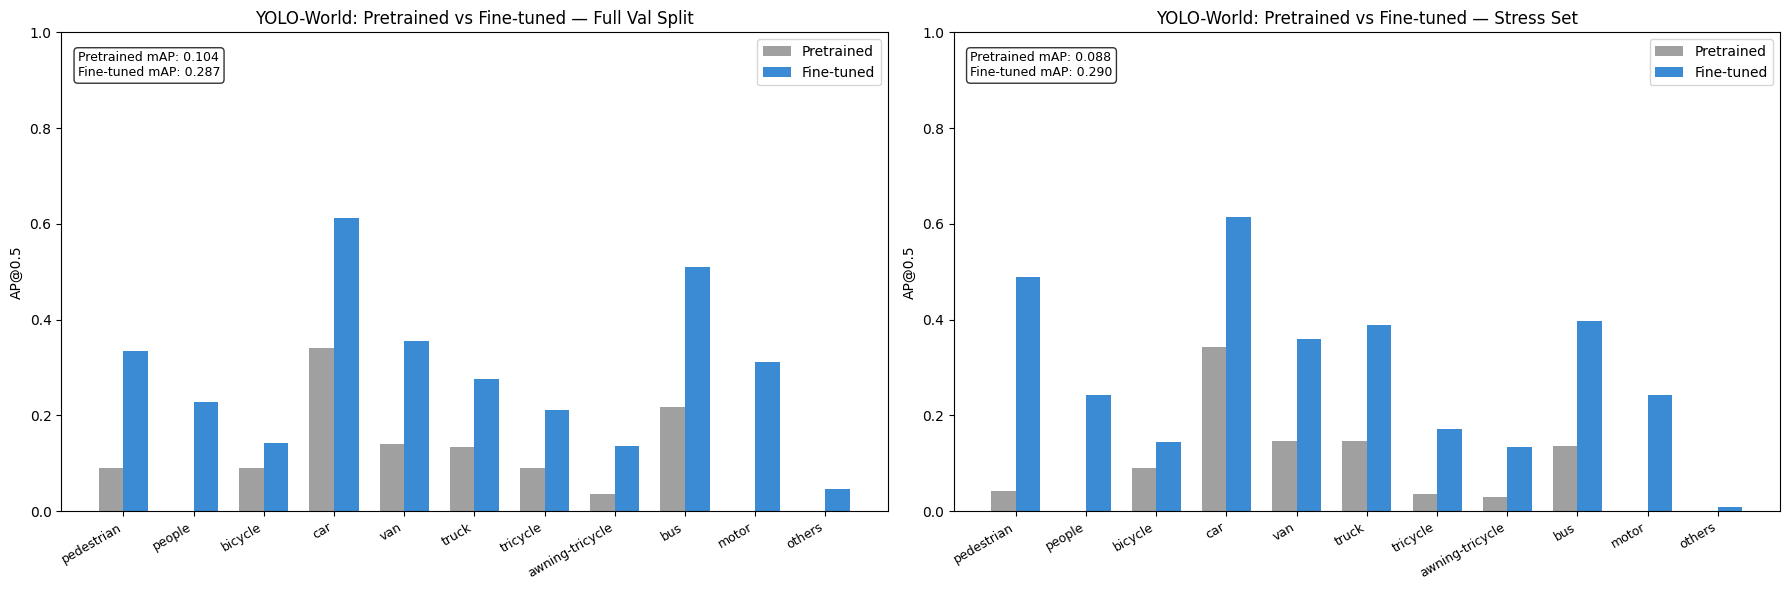

/tmp/ipykernel_5524/2684329852.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(YOLO_CLASSES, rotation=30, ha="right")


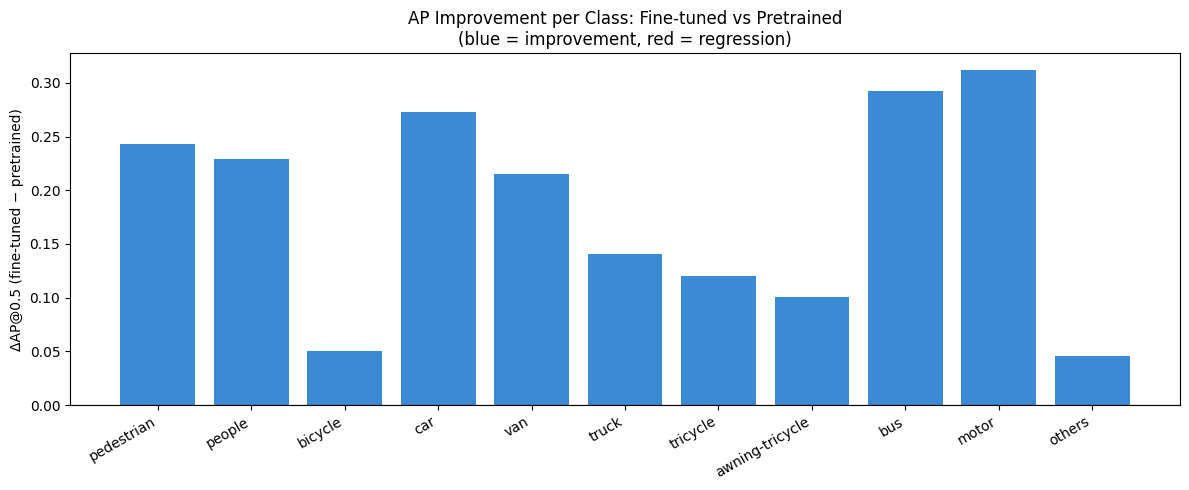

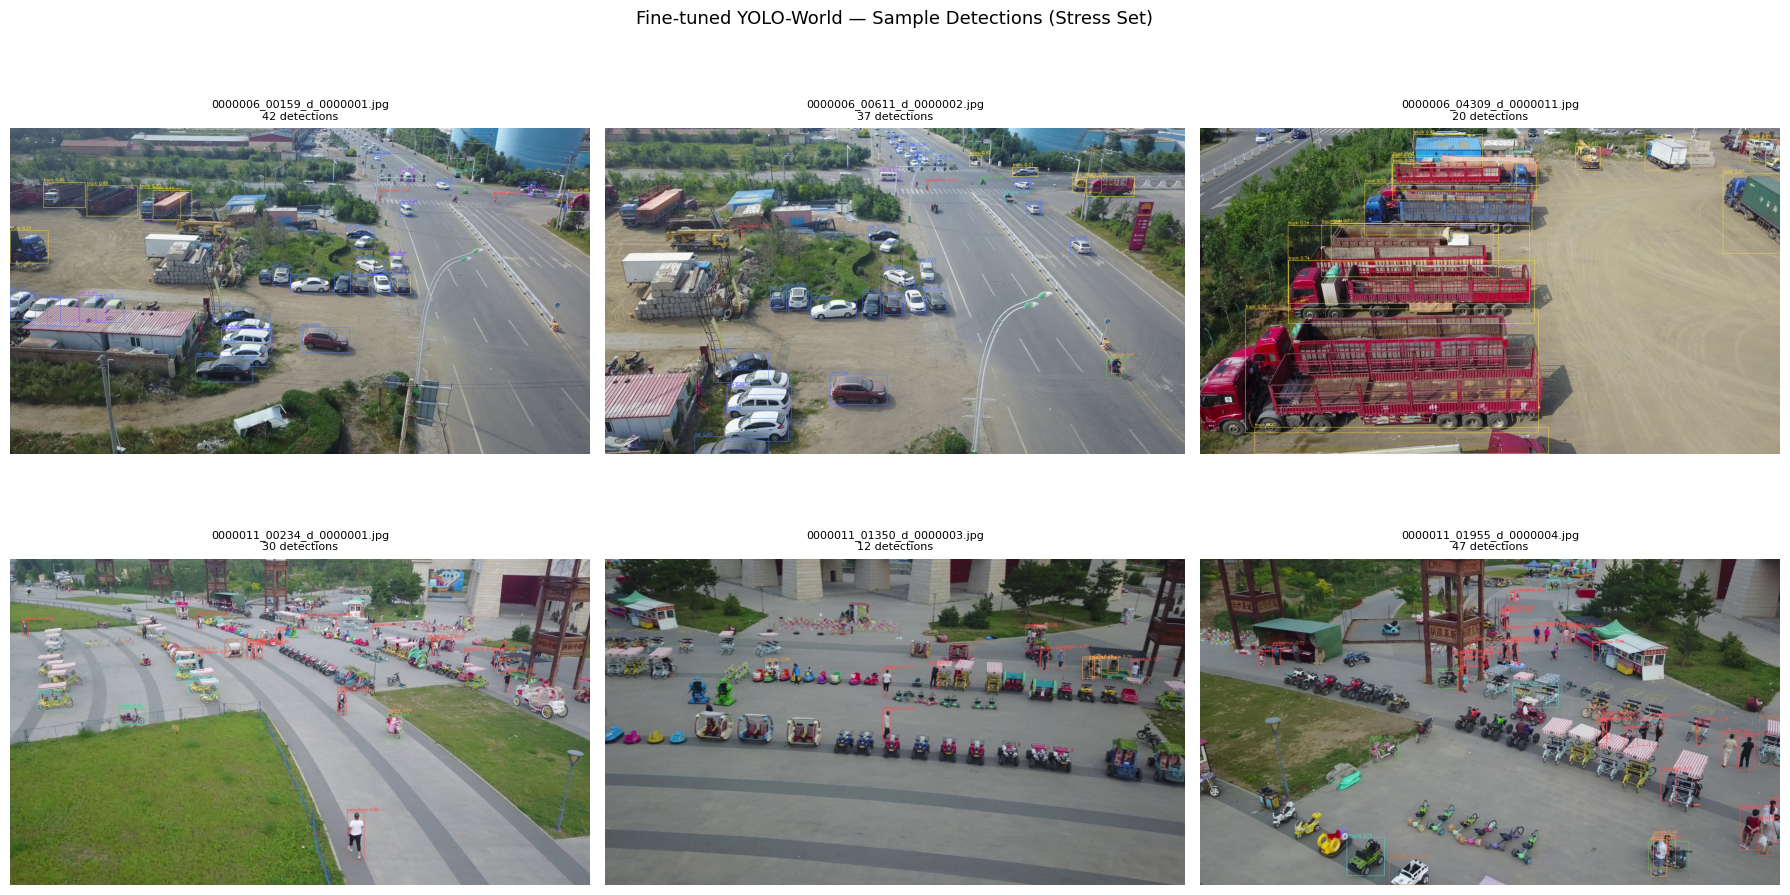

✅ All charts saved to staging.

Copying all outputs to Drive...
✅ Outputs extracted to Drive.

Verifying files on Drive:
  ✅ finetuned metrics JSON (0.9 KB)
  ✅ training results CSV (6.0 KB)
  ✅ comparison table (0.5 KB)
  ✅ AP comparison chart (58.7 KB)
  ✅ delta chart (53.8 KB)
  ✅ detection grid (2764.7 KB)
  ✅ fine-tuned checkpoint (93282.8 KB)

✅ All outputs confirmed on Drive. Notebook 03 complete.
   Next → 04_evaluation_comparison.ipynb


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 8: Load pretrained baseline, build comparison,
# save all outputs to Drive
# ─────────────────────────────────────────────────────────────

# ── Load pretrained baseline from Notebook 02 ────────────────
baseline_path = os.path.join(METRICS_DIR, "yoloworld_baseline.json")
if not os.path.exists(baseline_path):
    raise FileNotFoundError(
        f"Baseline metrics not found: {baseline_path}\n"
        "Run Notebook 02 first to generate the baseline."
    )
with open(baseline_path) as f:
    baseline = json.load(f)

map50_pt_full   = baseline["map50_full_val"]
map50_pt_stress = baseline["map50_stress_set"]
ap_pt_full      = baseline["per_class_ap_full"]
ap_pt_stress    = baseline["per_class_ap_stress"]

print("=" * 60)
print("  PRETRAINED vs FINE-TUNED COMPARISON")
print("=" * 60)
print(f"\n  {'Metric':<30} {'Pretrained':>12} {'Fine-tuned':>12} {'Δ':>8}")
print(f"  {'-'*62}")
print(f"  {'mAP@0.5 (full val)':<30} {map50_pt_full:>12.4f} "
      f"{map50_ft_full:>12.4f} {map50_ft_full-map50_pt_full:>+8.4f}")
print(f"  {'mAP@0.5 (stress set)':<30} {map50_pt_stress:>12.4f} "
      f"{map50_ft_stress:>12.4f} {map50_ft_stress-map50_pt_stress:>+8.4f}")
print(f"\n  Per-class AP@0.5 (full val):")
print(f"  {'Class':<22} {'Pretrained':>10} {'Fine-tuned':>10} {'Δ':>8}")
print(f"  {'-'*52}")
for cls in YOLO_CLASSES:
    pt = ap_pt_full.get(cls, 0)
    ft = ap_ft_full.get(cls, 0)
    delta = ft - pt
    arrow = "▲" if delta > 0.01 else ("▼" if delta < -0.01 else "─")
    print(f"  {cls:<22} {pt:>10.4f} {ft:>10.4f} {delta:>+8.4f} {arrow}")

# ── Save fine-tuned metrics JSON ──────────────────────────────
ft_metrics = {
    "model"              : "YOLO-World fine-tuned on VisDrone (yolov8l-world-finetuned.pt)",
    "dataset"            : "VisDrone val",
    "classes"            : YOLO_CLASSES,
    "map50_full_val"     : map50_ft_full,
    "map50_stress_set"   : map50_ft_stress,
    "per_class_ap_full"  : ap_ft_full,
    "per_class_ap_stress": ap_ft_stress,
}
with open(f"{STAGE_METRICS}/yoloworld_finetuned.json", "w") as f:
    json.dump(ft_metrics, f, indent=2)

# ── Save comparison CSV ───────────────────────────────────────
comparison_rows = []
for cls in YOLO_CLASSES:
    comparison_rows.append({
        "class"          : cls,
        "ap_pretrained"  : ap_pt_full.get(cls, 0),
        "ap_finetuned"   : ap_ft_full.get(cls, 0),
        "delta"          : round(ap_ft_full.get(cls,0) - ap_pt_full.get(cls,0), 4),
        "ap_stress_pre"  : ap_pt_stress.get(cls, 0),
        "ap_stress_ft"   : ap_ft_stress.get(cls, 0),
    })
df_compare = pd.DataFrame(comparison_rows)
df_compare.to_csv(f"{STAGE_TABLES}/comparison_pretrained_vs_finetuned.csv", index=False)
print("\n✅ Metrics and comparison table saved to staging.")

# ── Chart 1: Side-by-side per-class AP ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (pt_ap, ft_ap, title) in zip(axes, [
    (ap_pt_full, ap_ft_full, "Full Val Split"),
    (ap_pt_stress, ap_ft_stress, "Stress Set"),
]):
    x   = np.arange(len(YOLO_CLASSES))
    w   = 0.35
    apf = [pt_ap.get(c, 0) for c in YOLO_CLASSES]
    aps = [ft_ap.get(c, 0) for c in YOLO_CLASSES]
    ax.bar(x - w/2, apf, w, label="Pretrained",  color="#A0A0A0")
    ax.bar(x + w/2, aps, w, label="Fine-tuned",  color="#3B8BD4")
    ax.set_xticks(x)
    ax.set_xticklabels(YOLO_CLASSES, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("AP@0.5")
    ax.set_ylim(0, 1)
    ax.set_title(f"YOLO-World: Pretrained vs Fine-tuned — {title}")
    ax.legend()
    # annotate overall mAP
    pt_map = round(float(np.mean(apf)), 4)
    ft_map = round(float(np.mean(aps)), 4)
    ax.text(0.02, 0.96,
            f"Pretrained mAP: {pt_map:.3f}\nFine-tuned mAP: {ft_map:.3f}",
            transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
            fontsize=9)

plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/pretrained_vs_finetuned_ap.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Chart 2: Delta improvement per class ─────────────────────
deltas = [ap_ft_full.get(c, 0) - ap_pt_full.get(c, 0) for c in YOLO_CLASSES]
colors = ["#3B8BD4" if d >= 0 else "#E05C5C" for d in deltas]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(YOLO_CLASSES, deltas, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticklabels(YOLO_CLASSES, rotation=30, ha="right")
ax.set_ylabel("ΔAP@0.5 (fine-tuned − pretrained)")
ax.set_title("AP Improvement per Class: Fine-tuned vs Pretrained\n"
             "(blue = improvement, red = regression)")
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/ap_delta_per_class.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Chart 3: Sample detections from fine-tuned model ─────────
COLOR_MAP = {
    0:(255,80,80),  1:(255,160,80), 2:(80,180,80),  3:(80,120,255),
    4:(180,80,255), 5:(255,220,60), 6:(80,220,220),  7:(200,120,80),
    8:(255,100,180),9:(100,200,100),10:(180,180,180),
}
sample_imgs = sorted(os.listdir(STRESS_IMG_LOCAL))[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, img_file in enumerate(sample_imgs):
    img = cv2.imread(os.path.join(STRESS_IMG_LOCAL, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    res = ft_model.predict(img, verbose=False, conf=0.25)
    n = 0
    if res and res[0].boxes is not None:
        for box in res[0].boxes:
            cls_id = int(box.cls.item())
            x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].tolist()]
            color = COLOR_MAP.get(cls_id, (200,200,200))
            cv2.rectangle(img, (x1,y1), (x2,y2), color, 1)
            cv2.putText(img,
                        f"{YOLO_CLASSES[cls_id]} {float(box.conf.item()):.2f}",
                        (x1, max(0,y1-3)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, 1)
            n += 1
    axes[i].imshow(img)
    axes[i].set_title(f"{img_file}\n{n} detections", fontsize=8)
    axes[i].axis("off")
plt.suptitle("Fine-tuned YOLO-World — Sample Detections (Stress Set)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{STAGE_VIZ}/finetuned_sample_detections.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ All charts saved to staging.")

# ── Copy everything to Drive via tar + sync ───────────────────
print("\nCopying all outputs to Drive...")
TAR_PATH = "/content/staging/finetune_outputs.tar.gz"
subprocess.run(
    f"tar -czf {TAR_PATH} -C {STAGE} .",
    shell=True, check=True
)
subprocess.run(
    f"cp '{TAR_PATH}' '{OUTPUT_DIR}/' && sync",
    shell=True, check=True
)
subprocess.run(
    f"tar -xzf '{OUTPUT_DIR}/finetune_outputs.tar.gz' -C '{OUTPUT_DIR}'",
    shell=True, check=True
)
subprocess.run(
    f"rm '{OUTPUT_DIR}/finetune_outputs.tar.gz' && sync",
    shell=True, check=True
)
print("✅ Outputs extracted to Drive.")

# ── Verify ────────────────────────────────────────────────────
print("\nVerifying files on Drive:")
expected = [
    (os.path.join(METRICS_DIR,  "yoloworld_finetuned.json"),              "finetuned metrics JSON"),
    (os.path.join(METRICS_DIR,  "results.csv"),                           "training results CSV"),
    (os.path.join(TABLES_DIR,   "comparison_pretrained_vs_finetuned.csv"),"comparison table"),
    (os.path.join(VIZ_DIR,      "finetune_results", "pretrained_vs_finetuned_ap.png"), "AP comparison chart"),
    (os.path.join(VIZ_DIR,      "finetune_results", "ap_delta_per_class.png"),          "delta chart"),
    (os.path.join(VIZ_DIR,      "finetune_results", "finetuned_sample_detections.png"), "detection grid"),
    (YW_FT_CKPT_PATH,                                                     "fine-tuned checkpoint"),
]
all_ok = True
for path, label in expected:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    print(f"  {'✅' if exists else '❌'} {label} ({size:.1f} KB)")
    if not exists:
        all_ok = False

if all_ok:
    print("\n✅ All outputs confirmed on Drive. Notebook 03 complete.")
    print("   Next → 04_evaluation_comparison.ipynb")
else:
    print("\n❌ Some files missing — check staging and re-run Cell 8.")

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 9: Release VRAM
# ─────────────────────────────────────────────────────────────
import gc, torch

for obj in ["ft_model", "model", "results"]:
    if obj in dir():
        del globals()[obj]
gc.collect()
torch.cuda.empty_cache()

free_gb = torch.cuda.mem_get_info()[0]/1e9 if torch.cuda.is_available() else 0
print(f"✅ VRAM cleared. Free: {free_gb:.1f} GB")
print("   Notebook 03 complete.")

✅ VRAM cleared. Free: 41.6 GB
   Notebook 03 complete.
